In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris, fetch_openml

### Load Dataset

In [ ]:
iris = load_iris()
X = iris.data[:, :3]
y = iris.target
print(X.shape)

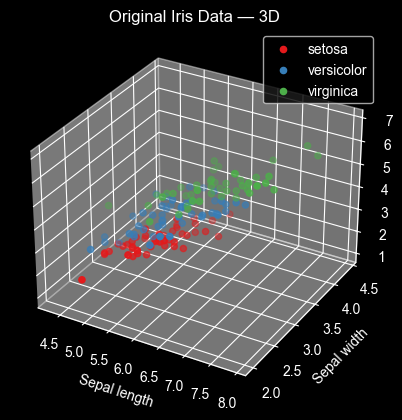

In [10]:
fig = plt.figure()
colors = ["#E41A1C", "#377EB8", "#4DAF4A"]  # red, blue, green
ax = fig.add_subplot(111, projection="3d")
for i, name in enumerate(iris.target_names):
    mask = y == i
    ax.scatter(X[mask, 0], X[mask, 1], X[mask, 2], label=name, color=colors[i])

ax.set_xlabel("Sepal length")
ax.set_ylabel("Sepal width")
ax.set_zlabel("Petal length")
ax.set_title("Original Iris Data — 3D")
ax.legend()
plt.show()

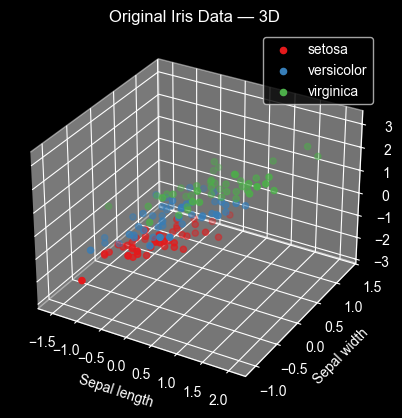

In [11]:
X_centered = X - X.mean(axis=0)

fig = plt.figure()
colors = ["#E41A1C", "#377EB8", "#4DAF4A"]  # red, blue, green
ax = fig.add_subplot(111, projection="3d")
for i, name in enumerate(iris.target_names):
    mask = y == i
    ax.scatter(X_centered[mask, 0], X_centered[mask, 1], X_centered[mask, 2], label=name, color=colors[i])

ax.set_xlabel("Sepal length")
ax.set_ylabel("Sepal width")
ax.set_zlabel("Petal length")
ax.set_title("Original Iris Data — 3D")
ax.legend()
plt.show()

### SVD

In [12]:
U, s, Vt = np.linalg.svd(X_centered)

### PCA

In [13]:
c1 = Vt[0]
c2 = Vt[1]
print("PC1:", c1)
print("PC2:", c2)

PC1: [ 0.38983343 -0.09100801  0.91637735]
PC2: [-0.63922328 -0.74305866  0.19813487]


In [22]:
W2 = Vt[:2].T
W2

array([[ 0.38983343, -0.63922328],
       [-0.09100801, -0.74305866],
       [ 0.91637735,  0.19813487]])

In [18]:
X_reduced = X_centered @ W2
print(X_reduced.shape)

(150, 3)


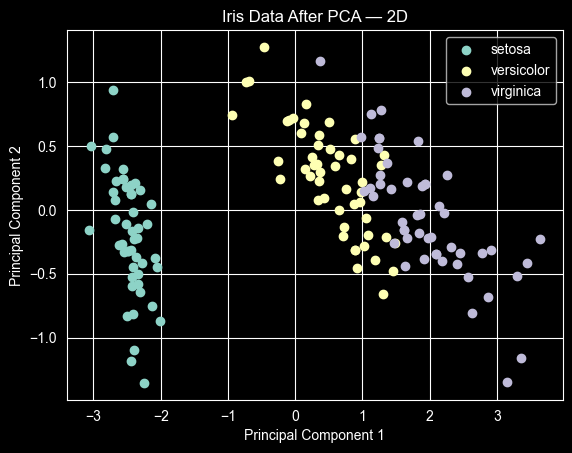

In [21]:
plt.figure()
for i, name in enumerate(iris.target_names):
    mask = y == i
    plt.scatter(X_reduced[mask, 0], X_reduced[mask, 1], label=name)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Data After PCA — 2D")
plt.legend()
plt.show()

end